In [200]:
#Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [201]:
current_dir = os.getcwd()

In [202]:
print(current_dir)

C:\Users\User\Desktop\UVM_Course\Data_Science_I\Project\SNAP-Diabetes-prevalance\data analysis


In [203]:
relative_path_segs = [
    '..', 
    'data processing', 
    'date_cleaned', 
    'all_merged_new.csv'
]

In [204]:
file_path = os.path.join(*relative_path_segs)

In [205]:
#Read in merged data
merged_data = pd.read_csv(file_path)
#merged_data = pd.read_csv('SNAP-Diabetes-prevalance/data processing/date_cleaned/merged_data.csv')

C:\Users\User\AppData\Local\Temp\ipykernel_19996\2965655807.py:2: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_data = pd.read_csv(file_path)


In [206]:
merged_data.head()

,high_threshold_in_state,per_fi_less_or_equal_to_low_threshold,county_name_x,food_insecurity_rate,per_fi_children_hh_income_above_185_fpl,fips,low_threshold_type,num_of_food_insecure_persons,cost_per_meal,child_food_insecurity_rate,...,diabetes_rate,obesity_rate,county_name_y,estimate_total_households,median_household_income,percent_families_wo_employment,per_hs_grad,per_col_grad,percent_white_only,percent_over65
0,1.85,0.327,autauga county,0.134,0.49,1001,snap,7140.0,2.580000,0.203,...,0.113,0.384,"Autauga County, Alabama",22308,68315,17.9,90.4,29.6,74.4,15.6
1,1.85,0.385,autauga county,0.136,0.37,1001,snap,7310.0,2.820000,0.196,...,0.113,0.384,"Autauga County, Alabama",22308,68315,17.9,90.4,29.6,74.4,15.6
2,1.85,0.423,autauga county,0.135,0.37,1001,snap,7360.0,2.986678,0.205,...,0.113,0.384,"Autauga County, Alabama",22308,68315,17.9,90.4,29.6,74.4,15.6
3,1.85,0.461,autauga county,0.139,0.31,1001,snap,7620.0,3.060000,0.215,...,0.113,0.384,"Autauga County, Alabama",22308,68315,17.9,90.4,29.6,74.4,15.6
4,1.85,0.451,autauga county,0.144,0.28,1001,snap,7930.0,3.160000,0.224,...,0.113,0.384,"Autauga County, Alabama",22308,68315,17.9,90.4,29.6,74.4,15.6


In [207]:
merged_data['median_household_income'] = pd.to_numeric(merged_data['median_household_income'], errors = "coerce")

In [208]:
merged_data.columns

Index(['high_threshold_in_state', 'per_fi_less_or_equal_to_low_threshold',
       'county_name_x', 'food_insecurity_rate',
       'per_fi_children_hh_income_above_185_fpl', 'fips', 'low_threshold_type',
       'num_of_food_insecure_persons', 'cost_per_meal',
       'child_food_insecurity_rate', 'num_of_food_insecure_children',
       'high_threshold_type', 'per_fi_children_hh_income_below_185_fpl',
       'state_name_raw', 'low_threshold_in_state', 'state_name',
       'weighted_annual_shortfall', 'per_fi_btwn_thresholds',
       'per_fi_greater_high_threshold', 'year', 'diabetes_rate',
       'obesity_rate', 'county_name_y', 'estimate_total_households',
       'median_household_income', 'percent_families_wo_employment',
       'per_hs_grad', 'per_col_grad', 'percent_white_only', 'percent_over65'],
      dtype='object')

In [209]:
numeric_cols = merged_data.select_dtypes(include='number').columns
annual_means = merged_data.groupby('year')[numeric_cols].mean()

annual_means

,high_threshold_in_state,per_fi_less_or_equal_to_low_threshold,food_insecurity_rate,per_fi_children_hh_income_above_185_fpl,fips,num_of_food_insecure_persons,cost_per_meal,child_food_insecurity_rate,num_of_food_insecure_children,per_fi_children_hh_income_below_185_fpl,...,year,diabetes_rate,obesity_rate,estimate_total_households,median_household_income,percent_families_wo_employment,per_hs_grad,per_col_grad,percent_white_only,percent_over65
year,,,,,,,,,,,,,,,,,,,,,
2010,1.875583,0.519989,0.155780,0.334114,30451.242734,14756.949856,2.517033,0.231109,5147.555982,0.665299,...,2010.0,0.111359,0.379272,39705.574257,63243.684984,18.622740,88.347748,23.453370,79.101821,19.719834
2011,1.875583,0.569579,0.147116,0.287538,30451.242734,14663.296072,2.628451,0.225347,5117.521559,0.711823,...,2011.0,0.111359,0.379272,39705.574257,63243.684984,18.622740,88.347748,23.453370,79.101821,19.719834
2012,1.878553,0.598477,0.147384,0.283168,30451.242734,14522.242095,2.738589,0.229691,5193.353561,0.717269,...,2012.0,0.111359,0.379272,39705.574257,63243.684984,18.622740,88.347748,23.453370,79.101821,19.719834
2013,1.881332,0.617092,0.150620,0.263292,30451.242734,14463.861386,2.788576,0.237332,5258.862983,0.737731,...,2013.0,0.111359,0.379272,39705.574257,63243.684984,18.622740,88.347748,23.453370,79.101821,19.719834
2014,1.881332,0.621665,0.146776,0.283271,30451.242734,14189.770042,2.888508,0.228122,4974.477803,0.717688,...,2014.0,0.111359,0.379272,39705.574257,63243.684984,18.622740,88.347748,23.453370,79.101821,19.719834
2015,1.881312,0.636493,0.141462,0.268666,30447.207469,13535.346313,2.938912,0.210994,4585.451644,0.732301,...,2015.0,0.111408,0.379317,39681.679221,63227.227331,18.624130,88.340919,23.442451,79.053814,19.711586
2016,1.881312,0.628092,0.137054,0.276939,30447.207469,13119.652091,2.998717,0.200816,4335.927226,0.724038,...,2016.0,0.111408,0.379317,39681.679221,63227.227331,18.624130,88.340919,23.442451,79.053814,19.711586
2017,1.887009,0.611593,0.132584,0.292400,30447.207469,12737.079477,3.018768,0.193799,4200.315991,0.708596,...,2017.0,0.111408,0.379317,39681.679221,63227.227331,18.624130,88.340919,23.442451,79.053814,19.711586
2018,1.887021,0.609967,0.132010,0.258978,30456.609195,12020.526820,3.088397,0.190744,3810.613027,0.741699,...,2018.0,0.111407,0.379315,39687.226373,63225.602363,18.624361,88.340262,23.440485,79.055300,19.712899


In [210]:
summary = (
    merged_data.groupby("year")["food_insecurity_rate"]
    .agg(
        mean = "mean",
        std="std",
        min="min",
        max="max",
        count="count"
    )
)

summary["range"] = summary["max"] - summary["min"]

print(summary)

          mean       std    min    max  count  range
year                                                
2010  0.155780  0.041774  0.045  0.374   3131  0.329
2011  0.147116  0.042571  0.024  0.352   3131  0.328
2012  0.147384  0.038553  0.039  0.328   3131  0.289
2013  0.150620  0.039197  0.042  0.334   3131  0.292
2014  0.146776  0.041353  0.043  0.375   3131  0.332
2015  0.141462  0.042392  0.034  0.379   3133  0.345
2016  0.137054  0.041882  0.037  0.361   3133  0.324
2017  0.132584  0.039630  0.029  0.363   3133  0.334
2018  0.132010  0.037659  0.036  0.304   3132  0.268
2019  0.131070  0.037203  0.029  0.294   3133  0.265
2020  0.124388  0.037215  0.026  0.287   3135  0.261
2021  0.114708  0.035757  0.022  0.263   3135  0.241
2022  0.144062  0.034725  0.058  0.288   3144  0.230


<Axes: xlabel='year'>

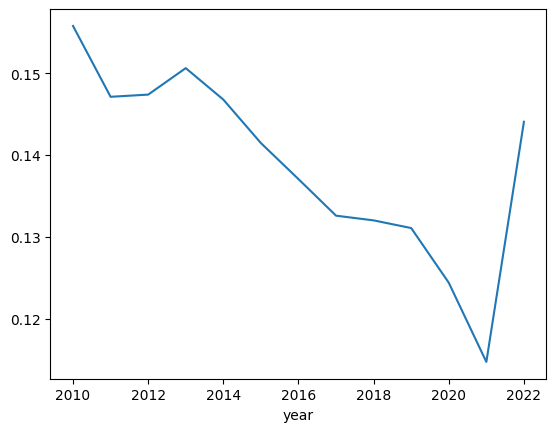

In [211]:
summary["mean"].plot(kind = "line")

In [212]:
census_health_df = merged_data[merged_data["year"] == 2022]

census_health_df = census_health_df[['fips', 'obesity_rate', 'diabetes_rate', 'median_household_income', 'percent_families_wo_employment', 'per_col_grad','per_hs_grad', 'percent_white_only', 'percent_over65']].drop_duplicates("fips")

census_health_df.notna().sum()

fips                              3144
obesity_rate                      3144
diabetes_rate                     3144
median_household_income           3143
percent_families_wo_employment    3144
per_col_grad                      3144
per_hs_grad                       3144
percent_white_only                3144
percent_over65                    3144
dtype: int64

In [213]:
fi = merged_data[["fips", "year", "food_insecurity_rate"]]

fi.isna().sum()

fips                    0
year                    0
food_insecurity_rate    0
dtype: int64

In [214]:
#Calculate various measures of change over time

#Overall mean 2010-2022
fi_mean_10_22 = fi.groupby("fips")["food_insecurity_rate"].mean().rename("fi_mean_10_22")

#Recent/Short-term exposure mean 2020-2022
fi_short = fi[fi["year"] >= 2020].groupby("fips")["food_insecurity_rate"].mean().rename("fi_short")

#Medium-term exposure mean
fi_medium = fi[fi["year"].isin([2015, 2016, 2017, 2018, 2019])].groupby("fips")["food_insecurity_rate"].mean().rename("fi_medium")

#Medium-term cumulative exposure
fi_medium_cumulative = fi[fi["year"].isin([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022])].groupby("fips")["food_insecurity_rate"].mean().rename("fi_medium_cumulative")

#Long-term exposure mean
fi_long = fi[fi["year"].isin([2010, 2011, 2012, 2013, 2014])].groupby("fips")["food_insecurity_rate"].mean().rename("fi_long")

#Food insecurity volatility - how much is a county's food insecurity rate fluctuating
fi_volatility_10_22 = fi.groupby("fips")["food_insecurity_rate"].std().rename("fi_volatility_10_22")

#Crude change between 2010 and 2022
fi_2010 = fi[fi["year"] == 2010].set_index("fips")["food_insecurity_rate"]
fi_2022 = fi[fi["year"] == 2022].set_index("fips")["food_insecurity_rate"]
fi_change_10_22 = (fi_2022 - fi_2010).rename("fi_change_10_22")


def calc_slope(group):
    years = group["year"].values
    fi_values = group["food_insecurity_rate"].values
    slope = np.polyfit(years, fi_values, 1)[0]
    return slope

fi_trend = fi.groupby("fips").apply(calc_slope).rename("fi_trend")

C:\Users\User\AppData\Local\Temp\ipykernel_19996\1749169708.py:30: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(years, fi_values, 1)[0]
C:\Users\User\AppData\Local\Temp\ipykernel_19996\1749169708.py:30: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(years, fi_values, 1)[0]
C:\Users\User\AppData\Local\Temp\ipykernel_19996\1749169708.py:30: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(years, fi_values, 1)[0]
C:\Users\User\AppData\Local\Temp\ipykernel_19996\1749169708.py:30: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(years, fi_values, 1)[0]
C:\Users\User\AppData\Local\Temp\ipykernel_19996\1749169708.py:30: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(years, fi_values, 1)[0]
C:\Users\User\AppData\Local\Temp\ipykernel_19996\1749169708.py:30: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(years, fi_values, 1)[0]
C:\Users\User\AppData\Local\Temp\ipykernel_199

In [215]:
#Merge all the change measures into one dataframe

fi_features = (
    pd.concat([fi_mean_10_22, fi_short, fi_medium, fi_medium_cumulative, fi_long, fi_volatility_10_22, fi_change_10_22, fi_trend], axis=1)
      .reset_index()
)

In [216]:
#Merge change measures with health and census data
final_df = fi_features.merge(census_health_df, on="fips", how="inner")
final_df

,fips,fi_mean_10_22,fi_short,fi_medium,fi_medium_cumulative,fi_long,fi_volatility_10_22,fi_change_10_22,fi_trend,obesity_rate,diabetes_rate,median_household_income,percent_families_wo_employment,per_col_grad,per_hs_grad,percent_white_only,percent_over65
0,1001,0.139917,0.143000,0.1405,0.141571,0.1376,0.007856,0.017,0.000933,0.384,0.113,68315.0,17.9,29.6,90.4,74.4,15.6
1,1003,0.130538,0.130333,0.1264,0.127875,0.1348,0.008847,0.015,-0.000319,0.368,0.102,71039.0,20.3,32.6,91.6,84.0,21.2
2,1005,0.216923,0.187667,0.2224,0.209375,0.2290,0.018590,-0.042,-0.004011,0.438,0.160,39712.0,26.2,11.9,76.5,45.5,19.8
3,1007,0.159615,0.168000,0.1552,0.160000,0.1590,0.011362,0.034,0.000868,0.414,0.133,50669.0,22.5,10.9,78.9,75.8,16.8
4,1009,0.128308,0.149667,0.1222,0.132500,0.1216,0.017974,0.048,0.002978,0.373,0.116,57440.0,20.1,14.7,81.8,91.3,18.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3139,56037,0.113692,0.126000,0.1108,0.116500,0.1092,0.011131,0.037,0.001692,0.363,0.094,79375.0,12.8,20.0,93.0,84.8,13.6
3140,56039,0.106923,0.095333,0.0966,0.096125,0.1242,0.016044,-0.011,-0.003313,0.222,0.071,108279.0,12.1,60.3,96.0,83.2,16.6
3141,56041,0.124615,0.115333,0.1312,0.125250,0.1236,0.010308,0.004,-0.000302,0.355,0.090,78164.0,13.3,19.1,94.4,91.3,15.6
3142,56043,0.116615,0.110333,0.1174,0.114750,0.1196,0.010421,0.024,-0.000390,0.391,0.094,61875.0,12.5,21.1,94.7,86.0,23.3


In [217]:
# Count of missing values per column
print(final_df.isna().sum())

fips                               0
fi_mean_10_22                      0
fi_short                           0
fi_medium                         11
fi_medium_cumulative               0
fi_long                           13
fi_volatility_10_22                9
fi_change_10_22                   13
fi_trend                           0
obesity_rate                       0
diabetes_rate                      0
median_household_income            1
percent_families_wo_employment     0
per_col_grad                       0
per_hs_grad                        0
percent_white_only                 0
percent_over65                     0
dtype: int64


In [218]:
rows_with_na = final_df[final_df['fi_medium'].isna()]

rows_with_na

,fips,fi_mean_10_22,fi_short,fi_medium,fi_medium_cumulative,fi_long,fi_volatility_10_22,fi_change_10_22,fi_trend,obesity_rate,diabetes_rate,median_household_income,percent_families_wo_employment,per_col_grad,per_hs_grad,percent_white_only,percent_over65
72,2063,0.095333,0.095333,NaN,0.095333,NaN,0.013317,NaN,0.009000,0.304,0.078,83068.0,10.1,31.5,94.5,71.6,13.2
73,2066,0.136000,0.136000,NaN,0.136000,NaN,0.026153,NaN,0.024000,0.326,0.089,70606.0,18.5,28.1,92.4,53.0,17.2
309,9110,0.131000,0.131000,NaN,0.131000,NaN,NaN,NaN,0.000032,0.324,0.094,88190.0,13.2,41.1,91.0,66.9,17.1
310,9120,0.150000,0.150000,NaN,0.150000,NaN,NaN,NaN,0.000037,0.287,0.090,83147.0,10.6,41.7,88.3,65.6,15.9
311,9130,0.102000,0.102000,NaN,0.102000,NaN,NaN,NaN,0.000025,0.312,0.077,99742.0,13.6,45.3,95.3,83.9,20.9
312,9140,0.136000,0.136000,NaN,0.136000,NaN,NaN,NaN,0.000034,0.309,0.089,82939.0,13.3,33.3,90.4,68.9,17.8
313,9150,0.127000,0.127000,NaN,0.127000,NaN,NaN,NaN,0.000031,0.328,0.084,83119.0,15.4,25.0,91.3,85.2,17.1
314,9160,0.127000,0.127000,NaN,0.127000,NaN,NaN,NaN,0.000031,0.306,0.082,87971.0,14.4,37.9,93.2,82.3,20.4
315,9170,0.135000,0.135000,NaN,0.135000,NaN,NaN,NaN,0.000033,0.320,0.096,83617.0,13.0,40.4,91.4,67.5,17.5
316,9180,0.134000,0.134000,NaN,0.134000,NaN,NaN,NaN,0.000033,0.334,0.091,80330.0,16.2,33.8,92.4,78.9,18.9


In [219]:
#Need to impute rows with NaN, these were rows where CT is missing due to change from counties to planning regions
# missing_med = final_df['fi_medium'].isna()
# missing_long = final_df['fi_long'].isna()
# missing_vol = final_df['fi_volatility_10_22'].isna()
# missing_change = final_df['fi_change_10_22'].isna()
# missing_income = final_df['median_household_income'].isna()

In [220]:
#Removing NAs for initial analyses
final_df = final_df.dropna()

correlation_matrix = final_df.corr()
correlation_matrix

,fips,fi_mean_10_22,fi_short,fi_medium,fi_medium_cumulative,fi_long,fi_volatility_10_22,fi_change_10_22,fi_trend,obesity_rate,diabetes_rate,median_household_income,percent_families_wo_employment,per_col_grad,per_hs_grad,percent_white_only,percent_over65
fips,1.000000,-0.136412,-0.070016,-0.135056,-0.115833,-0.157511,-0.088279,0.121827,0.127350,0.059692,0.013446,0.055645,-0.030674,0.041327,0.016692,0.104451,0.042880
fi_mean_10_22,-0.136412,1.000000,0.878755,0.986029,0.982640,0.964439,0.437940,-0.314326,-0.262028,0.470893,0.733219,-0.687724,0.464391,-0.429090,-0.524770,-0.497114,-0.045653
fi_short,-0.070016,0.878755,1.000000,0.847363,0.935686,0.744663,0.185411,0.114105,0.199259,0.477739,0.728589,-0.718824,0.519507,-0.522077,-0.602815,-0.291686,0.006206
fi_medium,-0.135056,0.986029,0.847363,1.000000,0.980225,0.934847,0.379620,-0.290997,-0.239164,0.478232,0.695890,-0.682191,0.460501,-0.416877,-0.467274,-0.470610,-0.024541
fi_medium_cumulative,-0.115833,0.982640,0.935686,0.980225,1.000000,0.898662,0.321332,-0.150831,-0.084657,0.495794,0.733897,-0.721155,0.499577,-0.471548,-0.535122,-0.421396,-0.013995
fi_long,-0.157511,0.964439,0.744663,0.934847,0.898662,1.000000,0.577663,-0.528302,-0.498924,0.407026,0.688046,-0.598628,0.386262,-0.342728,-0.478380,-0.575017,-0.088005
fi_volatility_10_22,-0.088279,0.437940,0.185411,0.379620,0.321332,0.577663,1.000000,-0.627599,-0.644518,0.178642,0.470283,-0.190781,0.053242,-0.038378,-0.348132,-0.606726,-0.165881
fi_change_10_22,0.121827,-0.314326,0.114105,-0.290997,-0.150831,-0.528302,-0.627599,1.000000,0.942551,0.006890,-0.118376,-0.030282,-0.009604,-0.079178,0.012933,0.465164,0.086791
fi_trend,0.127350,-0.262028,0.199259,-0.239164,-0.084657,-0.498924,-0.644518,0.942551,1.000000,0.037507,-0.081259,-0.070350,0.109012,-0.175694,-0.047681,0.482252,0.152876
obesity_rate,0.059692,0.470893,0.477739,0.478232,0.495794,0.407026,0.178642,0.006890,0.037507,1.000000,0.699370,-0.604003,0.223584,-0.657952,-0.470941,-0.193165,-0.070213


In [221]:
import seaborn as sns

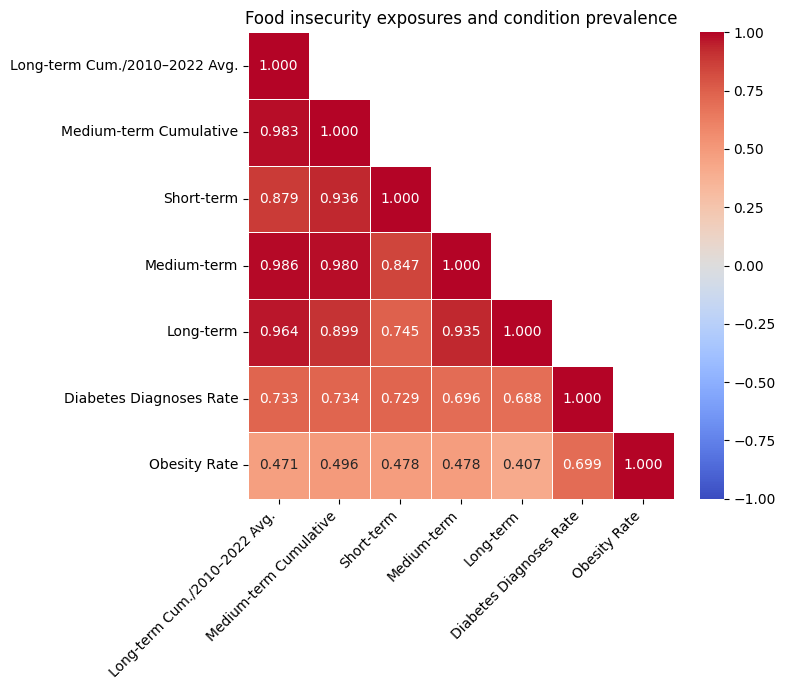

In [222]:
# Compute correlation matrix
corr = final_df[["fi_mean_10_22", "fi_medium_cumulative", "fi_short", "fi_medium", "fi_long", "diabetes_rate", "obesity_rate"]].corr()

#hide the upper triangle 
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(8, 7))
ax = sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt='.3f',
    linewidths=.5,
    vmin=-1, vmax=1,
    mask = mask
)

labels = ["Long-term Cum./2010–2022 Avg.", "Medium-term Cumulative", "Short-term", "Medium-term", "Long-term", "Diabetes Diagnoses Rate", "Obesity Rate"]

ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels, rotation=0)

plt.title("Food insecurity exposures and condition prevalence")
plt.tight_layout()
plt.show()

In [223]:
#Clustering, what types of clusters come out
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(final_df)

# Get cluster labels and centroids
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

print("Cluster labels:", labels)
print("Cluster centroids:", centroids)

Cluster labels: [0 0 2 ... 3 3 3]
Cluster centroids: [[ 1.97388274e+04  1.21170692e-01  1.08448388e-01  1.16950428e-01
   1.13762327e-01  1.33024480e-01  1.62150621e-02 -1.32937576e-02
  -2.58818192e-03  3.65554468e-01  9.93023256e-02  6.98564296e+04
   1.63342717e+01  2.57347613e+01  9.07492044e+01  8.28429621e+01
   1.93000000e+01]
 [ 3.53178401e+04  9.83392452e-02  8.62709751e-02  9.24775510e-02
   9.01500850e-02  1.11441901e-01  1.61517445e-02 -1.60292350e-02
  -2.84197822e-03  3.25289116e-01  9.24727891e-02  9.93630748e+04
   1.29486395e+01  3.99006803e+01  9.26309524e+01  7.56962585e+01
   1.66149660e+01]
 [ 1.85094824e+04  1.66565882e-01  1.53847843e-01  1.63890353e-01
   1.60124412e-01  1.76872235e-01  1.89327147e-02 -1.25600000e-02
  -2.33571429e-03  4.01982353e-01  1.23325882e-01  4.95649518e+04
   2.19195294e+01  1.80015294e+01  8.58234118e+01  7.60301176e+01
   2.04292941e+01]
 [ 4.53818760e+04  1.41067513e-01  1.32400912e-01  1.36584089e-01
   1.35015398e-01  1.50750898e-0

In [224]:
centroids_df = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=final_df.columns  # or the list of feature names
)
centroids_df

#Clusters with both food insecurity and health and census data

,fips,fi_mean_10_22,fi_short,fi_medium,fi_medium_cumulative,fi_long,fi_volatility_10_22,fi_change_10_22,fi_trend,obesity_rate,diabetes_rate,median_household_income,percent_families_wo_employment,per_col_grad,per_hs_grad,percent_white_only,percent_over65
0,19738.827417,0.121171,0.108448,0.116950,0.113762,0.133024,0.016215,-0.013294,-0.002588,0.365554,0.099302,69856.429621,16.334272,25.734761,90.749204,82.842962,19.300000
1,35317.840136,0.098339,0.086271,0.092478,0.090150,0.111442,0.016152,-0.016029,-0.002842,0.325289,0.092473,99363.074830,12.948639,39.900680,92.630952,75.696259,16.614966
2,18509.482353,0.166566,0.153848,0.163890,0.160124,0.176872,0.018933,-0.012560,-0.002336,0.401982,0.123326,49564.951765,21.919529,18.001529,85.823412,76.030118,20.429294
3,45381.875962,0.141068,0.132401,0.136584,0.135015,0.150751,0.017182,-0.009005,-0.001999,0.385967,0.115847,59484.241232,19.267921,21.706672,87.420445,79.563730,20.264842


In [225]:
#Make clusters based on food insecurity data only
fi_measures = [
    'fi_mean_10_22',
    'fi_short',
    'fi_medium',
    'fi_long',
    'fi_volatility_10_22',
    'fi_change_10_22',
    'fi_trend'
]

X = final_df[fi_measures]

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

centroids_df_fi = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=fi_measures  # or the list of feature names
)
centroids_df_fi



,fi_mean_10_22,fi_short,fi_medium,fi_long,fi_volatility_10_22,fi_change_10_22,fi_trend
0,0.165014,0.161262,0.161387,0.170894,0.016198,0.000613,-0.000978
1,0.095606,0.086709,0.091423,0.105128,0.014255,-0.005367,-0.001954
2,0.207943,0.167612,0.206172,0.233913,0.032938,-0.063677,-0.007069
3,0.131234,0.120195,0.126434,0.142658,0.016392,-0.012494,-0.002410


In [226]:
final_df['fi_cluster'] = labels

cluster_profile = final_df.groupby('fi_cluster').mean(numeric_only=True)
cluster_profile

C:\Users\User\AppData\Local\Temp\ipykernel_19996\149488223.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['fi_cluster'] = labels


,fips,fi_mean_10_22,fi_short,fi_medium,fi_medium_cumulative,fi_long,fi_volatility_10_22,fi_change_10_22,fi_trend,obesity_rate,diabetes_rate,median_household_income,percent_families_wo_employment,per_col_grad,per_hs_grad,percent_white_only,percent_over65
fi_cluster,,,,,,,,,,,,,,,,,
0,30583.304398,0.165014,0.161262,0.161387,0.161340,0.170894,0.016198,0.000613,-0.000978,0.397003,0.124925,52369.156250,21.753009,18.617245,85.259838,78.530787,19.771065
1,32525.868938,0.095606,0.086709,0.091423,0.089655,0.105128,0.014255,-0.005367,-0.001954,0.359018,0.092851,78375.246396,14.789777,28.977982,91.831193,86.149803,19.705505
2,24329.964539,0.207943,0.167612,0.206172,0.191712,0.233913,0.032938,-0.063677,-0.007069,0.428677,0.146748,45689.985816,22.411702,17.257447,83.005674,49.703901,18.704610
3,30460.505324,0.131234,0.120195,0.126434,0.124095,0.142658,0.016392,-0.012494,-0.002410,0.368014,0.105165,65537.177723,17.943079,24.873382,89.582883,81.878460,19.914169


## Predictive analysis

In [227]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, roc_curve, f1_score, auc
from sklearn.linear_model import LinearRegression

In [228]:
final_df.columns

Index(['fips', 'fi_mean_10_22', 'fi_short', 'fi_medium',
       'fi_medium_cumulative', 'fi_long', 'fi_volatility_10_22',
       'fi_change_10_22', 'fi_trend', 'obesity_rate', 'diabetes_rate',
       'median_household_income', 'percent_families_wo_employment',
       'per_col_grad', 'per_hs_grad', 'percent_white_only', 'percent_over65',
       'fi_cluster'],
      dtype='object')

In [229]:
avg_diabetes = final_df["diabetes_rate"].mean()

avg_obesity = final_df["obesity_rate"].mean()

final_df["above_avg_diabetes"] = (final_df["diabetes_rate"] > avg_diabetes).astype(int)
final_df["above_avg_obesity"] = (final_df["obesity_rate"] > avg_obesity).astype(int)

C:\Users\User\AppData\Local\Temp\ipykernel_19996\3288974976.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df["above_avg_diabetes"] = (final_df["diabetes_rate"] > avg_diabetes).astype(int)
C:\Users\User\AppData\Local\Temp\ipykernel_19996\3288974976.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df["above_avg_obesity"] = (final_df["obesity_rate"] > avg_obesity).astype(int)


In [230]:
X = final_df[['fi_mean_10_22', 'median_household_income', 'per_hs_grad', 'percent_white_only', 'percent_over65']]

y = final_df['above_avg_diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators = 300,
    max_depth = None,
    random_state = 42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall/Specificity:", recall_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8626198083067093
Precision: 0.8458781362007168
Recall/Specificity: 0.8458781362007168
[[304  43]
 [ 43 236]]
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       347
           1       0.85      0.85      0.85       279

    accuracy                           0.86       626
   macro avg       0.86      0.86      0.86       626
weighted avg       0.86      0.86      0.86       626



In [231]:
X = final_df[['fi_mean_10_22', 'median_household_income', 'per_hs_grad', 'percent_white_only', 'percent_over65']]

y = final_df['above_avg_obesity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators = 300,
    max_depth = None,
    random_state = 42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall/Specificity:", recall_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7236421725239617
Precision: 0.7402234636871509
Recall/Specificity: 0.7681159420289855
[[188  93]
 [ 80 265]]
              precision    recall  f1-score   support

           0       0.70      0.67      0.68       281
           1       0.74      0.77      0.75       345

    accuracy                           0.72       626
   macro avg       0.72      0.72      0.72       626
weighted avg       0.72      0.72      0.72       626



### Diabetes model

Average model performance (5-fold CV)
Mean Accuracy:   0.506 (Std: 0.013)
Mean Precision:  0.458 (Std: 0.012)
Mean Recall:     0.587 (Std: 0.015)
Mean F1-Score:   0.515 (Std: 0.013)
Mean AUC:        0.939 (Std: 0.007)


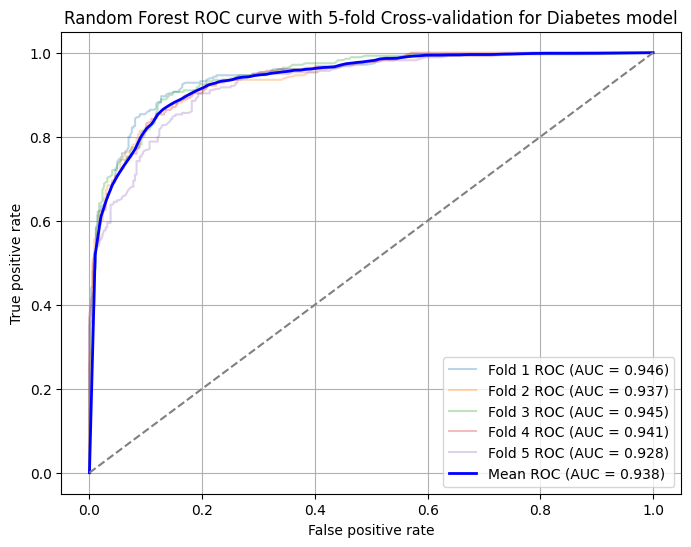

In [232]:
X = final_df[['fi_mean_10_22', 'median_household_income', 'per_hs_grad', 'percent_white_only', 'percent_over65']]

y = final_df['above_avg_diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators = 300,
    max_depth = None,
    random_state = 42
)
kf = StratifiedKFold(n_splits = 5, shuffle = True, random_state=42)

#Store metrics 
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

tprs = []
aucs = []

mean_fpr = np.linspace(0,1,100)

plt.figure(figsize=(8,6))

for fold, (train_idx, test_idx) in enumerate(kf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Fit model
    rf.fit(X_train, y_train)

    # Predict probabilities
    y_prob = rf.predict_proba(X_test)[:, 1]

    #Store metrics for each fold 
    accuracy_scores.append(accuracy_score(y_test, y_pred))
    precision_scores.append(precision_score(y_test, y_pred, zero_division=0))
    recall_scores.append(recall_score(y_test, y_pred, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred, zero_division=0))

    # Compute ROC curve + AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    # Interpolate ROC for mean curve
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0

    # Plot each fold
    plt.plot(fpr, tpr, alpha=0.3, label=f"Fold {fold} ROC (AUC = {roc_auc:.3f})")

#Average metrics output 
mean_accuracy = np.mean(accuracy_scores)
mean_precision = np.mean(precision_scores)
mean_recall = np.mean(recall_scores)
mean_f1 = np.mean(f1_scores)
print("Average model performance (5-fold CV)")
print(f"Mean Accuracy:   {mean_accuracy:.3f} (Std: {np.std(accuracy_scores):.3f})")
print(f"Mean Precision:  {mean_precision:.3f} (Std: {np.std(precision_scores):.3f})")
print(f"Mean Recall:     {mean_recall:.3f} (Std: {np.std(recall_scores):.3f})")
print(f"Mean F1-Score:   {mean_f1:.3f} (Std: {np.std(f1_scores):.3f})")
print(f"Mean AUC:        {np.mean(aucs):.3f} (Std: {np.std(aucs):.3f})")

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)

plt.plot(
    mean_fpr, mean_tpr,
    color="blue",
    lw=2,
    label=f"Mean ROC (AUC = {mean_auc:.3f})"
)

# Plot chance line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

# Formatting
plt.title("Random Forest ROC curve with 5-fold Cross-validation for Diabetes model")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend(loc="lower right")
plt.grid(True)
#plt.savefig("../data viz/random_forest_diabetes_roc.png")
plt.show()

### Obesity model

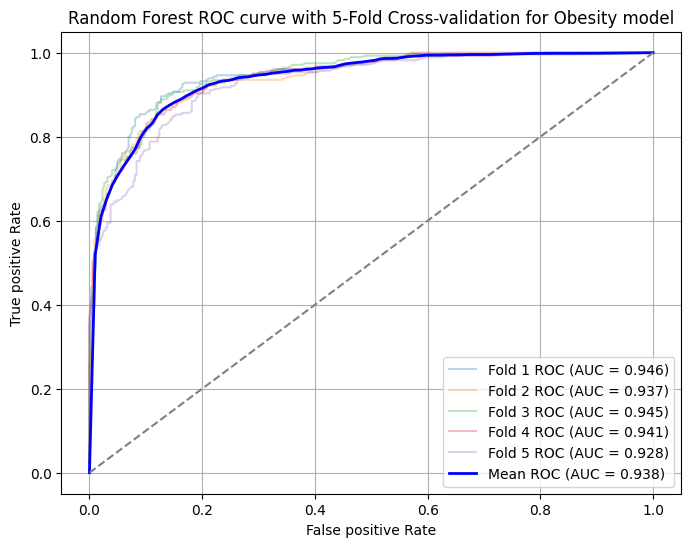

In [233]:
X_obesity = final_df[['fi_mean_10_22', 'median_household_income', 'per_hs_grad', 'percent_white_only', 'percent_over65']]

y_obesity = final_df['above_avg_obesity']

X_train, X_test, y_train, y_test = train_test_split(
    X_obesity, y_obesity , test_size=0.2, random_state=123, stratify=y
)

rf = RandomForestClassifier(
    n_estimators = 300,
    max_depth = None,
    random_state = 42
)
kf = StratifiedKFold(n_splits = 5, shuffle = True, random_state=42)

tprs = []
aucs = []

mean_fpr = np.linspace(0,1,100)

plt.figure(figsize=(8,6))

for fold, (train_idx, test_idx) in enumerate(kf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Fit model
    rf.fit(X_train, y_train)

    # Predict probabilities
    y_prob = rf.predict_proba(X_test)[:, 1]

    # Compute ROC curve + AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    # Interpolate ROC for mean curve
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0

    # Plot each fold
    plt.plot(fpr, tpr, alpha=0.3, label=f"Fold {fold} ROC (AUC = {roc_auc:.3f})")

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)

plt.plot(
    mean_fpr, mean_tpr,
    color="blue",
    lw=2,
    label=f"Mean ROC (AUC = {mean_auc:.3f})"
)

# Plot chance line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

# Formatting
plt.title("Random Forest ROC curve with 5-Fold Cross-validation for Obesity model")
plt.xlabel("False positive Rate")
plt.ylabel("True positive Rate")
plt.legend(loc="lower right")
plt.savefig("../data viz/random_forest_obesity_roc.png")
plt.grid(True)
plt.show()

In [234]:
def run_rf_classification_cv(X, y, outcome_name, n_splits=5, random_state=42, n_estimators=300, save_path="../data viz"):
    
    # Initialize model and cross-validator
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=None,
        random_state=random_state
    )
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # Initialize storage for metrics and ROC plotting
    accuracy_scores, precision_scores, recall_scores, f1_scores, aucs = [], [], [], [], []
    tprs = []
    mean_fpr = np.linspace(0, 1, 100)

    print(f"\n--- Starting {n_splits}-Fold CV for {outcome_name} Model ---")
    plt.figure(figsize=(8, 6))

    #CV loop 
    for fold, (train_idx, test_idx) in enumerate(kf.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Fit model
        rf.fit(X_train, y_train)

        #Classification metrics
        y_pred = rf.predict(X_test)
        accuracy_scores.append(accuracy_score(y_test, y_pred))
        precision_scores.append(precision_score(y_test, y_pred, zero_division=0))
        recall_scores.append(recall_score(y_test, y_pred, zero_division=0))
        f1_scores.append(f1_score(y_test, y_pred, zero_division=0))

        #ROC curve metrics
        y_prob = rf.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)

        #Interpolate ROC for mean curve
        tprs.append(np.interp(mean_fpr, fpr, tpr))
        tprs[-1][0] = 0.0

        # Plot individual fold ROC
        plt.plot(fpr, tpr, alpha=0.3, lw=1, label=f"Fold {fold} ROC (AUC = {roc_auc:.3f})")

    #Print Average Metrics
    mean_accuracy = np.mean(accuracy_scores)
    mean_precision = np.mean(precision_scores)
    mean_recall = np.mean(recall_scores)
    mean_f1 = np.mean(f1_scores)
    mean_auc = np.mean(aucs)

    print(f"  Average Model Performance: {outcome_name} (5-Fold CV)")
    print(f"Mean Accuracy:   {mean_accuracy:.4f} (Std: {np.std(accuracy_scores):.4f})")
    print(f"Mean Precision:  {mean_precision:.4f} (Std: {np.std(precision_scores):.4f})")
    print(f"Mean Recall:     {mean_recall:.4f} (Std: {np.std(recall_scores):.4f})")
    print(f"Mean F1-Score:   {mean_f1:.4f} (Std: {np.std(f1_scores):.4f})")
    print(f"Mean AUC:        {mean_auc:.4f} (Std: {np.std(aucs):.4f})")

    #Plot Mean ROC Curve
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    std_auc = np.std(aucs)

    plt.plot(
        mean_fpr, mean_tpr,
        color="blue",
        lw=2,
        label=f"Mean ROC (AUC = {mean_auc:.3f} $\pm$ {std_auc:.3f})"
    )

    # Formatting and Saving
    plt.title(f"Random Forest ROC curve with 5-fold CV for {outcome_name} model")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid(True)
    
    filename = f"random_forest_{outcome_name.lower().replace(' ', '_')}_roc.png"
    full_path = f"{save_path}/{filename}"
    plt.savefig(full_path)
    plt.show()

    print(f"\nSaved ROC curve plot as '{full_path}'")
    
    return {
        'mean_accuracy': mean_accuracy,
        'mean_precision': mean_precision,
        'mean_recall': mean_recall,
        'mean_auc': mean_auc
    }

In [235]:
rf_features = ['fi_mean_10_22', 'median_household_income', 'per_hs_grad', 'percent_white_only', 'percent_over65']


--- Starting 5-Fold CV for Diabetes Model ---
  Average Model Performance: Diabetes (5-Fold CV)
Mean Accuracy:   0.8642 (Std: 0.0133)
Mean Precision:  0.8561 (Std: 0.0192)
Mean Recall:     0.8367 (Std: 0.0259)
Mean F1-Score:   0.8460 (Std: 0.0163)
Mean AUC:        0.9393 (Std: 0.0066)


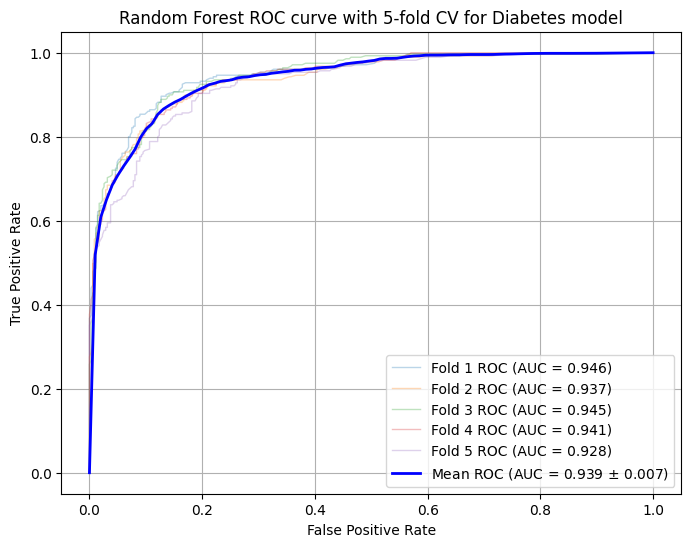


Saved ROC curve plot as '../data viz/random_forest_diabetes_roc.png'


In [236]:
#Run classification for Diabetes 
X_diabetes = final_df[rf_features]
y_diabetes = final_df['above_avg_diabetes']
diabetes_results = run_rf_classification_cv(X_diabetes, y_diabetes, 'Diabetes')


--- Starting 5-Fold CV for Obesity Model ---
  Average Model Performance: Obesity (5-Fold CV)
Mean Accuracy:   0.7284 (Std: 0.0107)
Mean Precision:  0.7531 (Std: 0.0038)
Mean Recall:     0.7556 (Std: 0.0295)
Mean F1-Score:   0.7540 (Std: 0.0146)
Mean AUC:        0.8119 (Std: 0.0072)


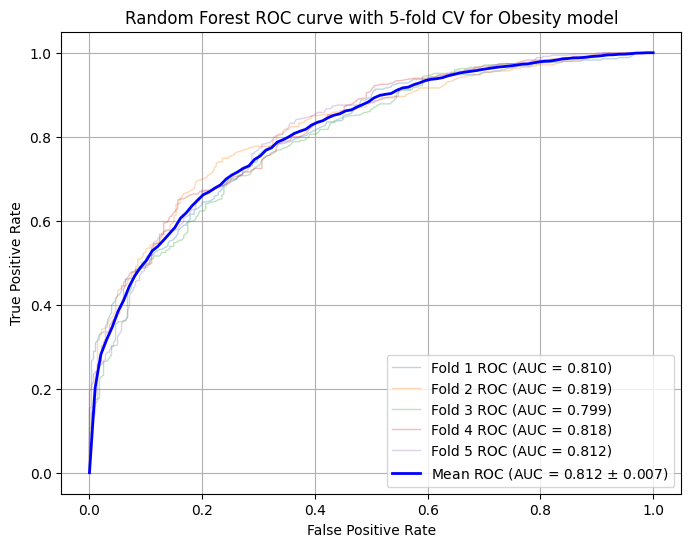


Saved ROC curve plot as '../data viz/random_forest_obesity_roc.png'


In [237]:
#Run classification for Obesity
X_obesity = final_df[rf_features]
y_obesity = final_df['above_avg_obesity']
obesity_results = run_rf_classification_cv(X_obesity, y_obesity, 'Obesity')

### Improved model with tuning 

In [238]:
from sklearn.model_selection import GridSearchCV

In [239]:
def run_rf_classification_cv_with_tuning(X, y, outcome_name, n_splits=5, random_state=123):

    # Small hyperparameter grid
    param_grid = {
        "n_estimators": [100, 200, 300, 400],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5]
    }

    base_rf = RandomForestClassifier(random_state=random_state)

    grid_search = GridSearchCV(
        estimator=base_rf,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=n_splits,
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X, y)
    best_params = grid_search.best_params_

    print("Best hyperparameters")
    print(best_params)

    # 2. Re-fit RF with best params
    best_rf = RandomForestClassifier(
        random_state=random_state,
        **best_params
    )

    # === Your original cross-validation code ===
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    accuracy_scores, precision_scores, recall_scores, f1_scores, aucs = [], [], [], [], []

    tprs = []
    mean_fpr = np.linspace(0, 1, 100)

    plt.figure(figsize=(8, 6))

    for fold, (train_idx, test_idx) in enumerate(kf.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        best_rf.fit(X_train, y_train)
        y_pred = best_rf.predict(X_test)
        y_prob = best_rf.predict_proba(X_test)[:, 1]

        accuracy_scores.append(accuracy_score(y_test, y_pred))
        precision_scores.append(precision_score(y_test, y_pred, zero_division=0))
        recall_scores.append(recall_score(y_test, y_pred, zero_division=0))
        f1_scores.append(f1_score(y_test, y_pred, zero_division=0))

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        aucs.append(auc(fpr, tpr))

        tprs.append(np.interp(mean_fpr, fpr, tpr))
        tprs[-1][0] = 0.0
        std_auc = np.std(aucs)

        plt.plot(fpr, tpr, alpha=0.3)

    mean_auc = np.mean(aucs)
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0

    plt.plot(mean_fpr, mean_tpr, color="blue", lw=2,
             label=f"Mean ROC (AUC={mean_auc:.3f} $\pm$ {std_auc:.3f})")
    plt.legend()
    plt.title(f"Random Forest ROC ({outcome_name})")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


    # === Feature Importance ===
    feature_importance = pd.Series(best_rf.feature_importances_, index=X.columns)
    feature_importance = feature_importance.sort_values(ascending=False)

    print("Feature importances")
    print(feature_importance)

    return {
        "best_params": best_params,
        "mean_accuracy": np.mean(accuracy_scores),
        "mean_precision": np.mean(precision_scores),
        "mean_recall": np.mean(recall_scores),
        "mean_f1": np.mean(f1_scores),
        "mean_auc": mean_auc,
        "feature_importance": feature_importance
    }

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best hyperparameters
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 400}


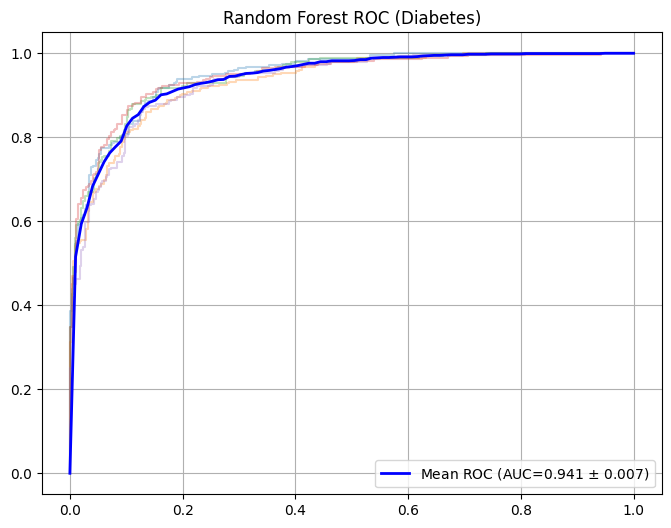

Feature importances
per_hs_grad                0.346835
fi_mean_10_22              0.281895
median_household_income    0.159258
percent_white_only         0.122014
percent_over65             0.089998
dtype: float64


In [240]:
#Run classification for Diabetes 
X_diabetes = final_df[rf_features]
y_diabetes = final_df['above_avg_diabetes']
diabetes_results = run_rf_classification_cv_with_tuning(X_diabetes, y_diabetes, 'Diabetes', n_splits=5, random_state=123)

In [ ]:
# Run Obesity model 
X_obesity = final_df[rf_features]
y_obesity = final_df['above_avg_obesity']
obesity_results = run_rf_classification_cv_with_tuning(X_obesity, y_obesity, 'Obesity', n_splits=5, random_state=123)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
